# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [28]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

### Cargar Dataset

In [29]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [30]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` se encontraba almacenada como float64, aunque representa una variable discreta (años cumplidos). Se convirtió a int64 para reflejar mejor la naturaleza de los datos.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [31]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype(int)

In [32]:

# verificar cambios
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [33]:

# Estadísticas descriptivas de variables numéricas
columnas_numericas=['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
df[columnas_numericas].describe().round(2)


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,38.26,30019.70,10.03,1.21,20.15,3.60,36.59
std,11.49,9833.17,3.16,1.11,10.88,0.69,34.48
min,18.00,8000.00,1.00,0.00,0.00,1.00,0.00
25%,30.00,23127.10,8.00,0.00,12.31,3.10,0.00
50%,38.00,30023.74,10.00,1.00,19.73,3.60,30.70
75%,46.00,36768.44,12.00,2.00,27.29,4.10,58.22
max,75.00,74790.84,25.00,8.00,75.51,5.00,244.69


Diagnóstico inicial de variables numéricas

- `edad` — Rango de 18 a 75 años, con media (38.26) y mediana (38.00) casi idénticas lo que sugiere una distribución bastante simétrica.
- `nivel_ingreso` — Media (30019.70) y mediana (30023.74) muy parecidas, pero el máximo (74790.84) está muy por encima del percentil 75, lo que indica outliers.
- `visitas_mes` — Distribución razonablemente simétrica media (10.03) y mediana (10.00), pero el máximo (25) se aleja bastante del percentil 75 (12), lo que apunta a algunos outliers.
- `compras_mes` — el percentil 25 es 0, la mediana es apenas 1, y el máximo es 8. Es decir la variable está sesgada a la derecha.
- `gasto_publicidad_dirigida` — el máximo (75.51) casi triplica el percentil 75 (27.29), lo que indica cola derecha y posibles outliers.
- `satisfaccion` — Media (3.60) y mediana (3.60) coinciden, distribución simétrica y sin outliers
- `ingreso_anual` — el percentil 25 es 0.00, la desviación estándar (34.48) es casi igual a la media (36.59), y el máximo (244.69) es más de 4 veces el percentil 75 (58.22), esto indica posible desviación a la derecha y outliers.

#### Explorar variables binarias

In [34]:

# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias=['miembro_premium','abandono']
for columna in columnas_binarias:
    print(f"\n{columna}:")
    print(df[columna].value_counts())



miembro_premium:
0    12911
1     2089
Name: miembro_premium, dtype: int64

abandono:
0    12739
1     2261
Name: abandono, dtype: int64


Diagnóstico inicial de variables binarias

- `miembro_premium` — las categorías se encuentran desbalanceadas, cerca del 15% de usuarios son miembros premium, mientras que el resto no lo son.
- `abandono` — las categorías se encuentran desbalanceadas, cerca del 15% de usuarios han abandonado, mientras que el resto no.


#### Explorar variables categóricas

In [35]:


# Verificar el número de valores únicos por variable categórica

for columna in columnas_categoricas:
    print(f"\n{columna}:")
    print(df[columna].unique())




tipo_dispositivo:
['móvil' 'tablet' 'escritorio']

region:
['norte' 'sur' 'este' 'oeste']


In [36]:

# Explorar variables categóricas y cómo se distribuyen
columnas_categoricas=['tipo_dispositivo','region']
for columna in columnas_categoricas:
    print(f"\n{columna}:")
    print(df[columna].value_counts())




tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — se encuentran categorias desbalanceadas, la mayoria de los usuarios ocupan como dispositivo un movil.
- `region` — la region con mayor cantidad de usuarios es el Norte, pero no existen grandes diferencias entre las regiones. 


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

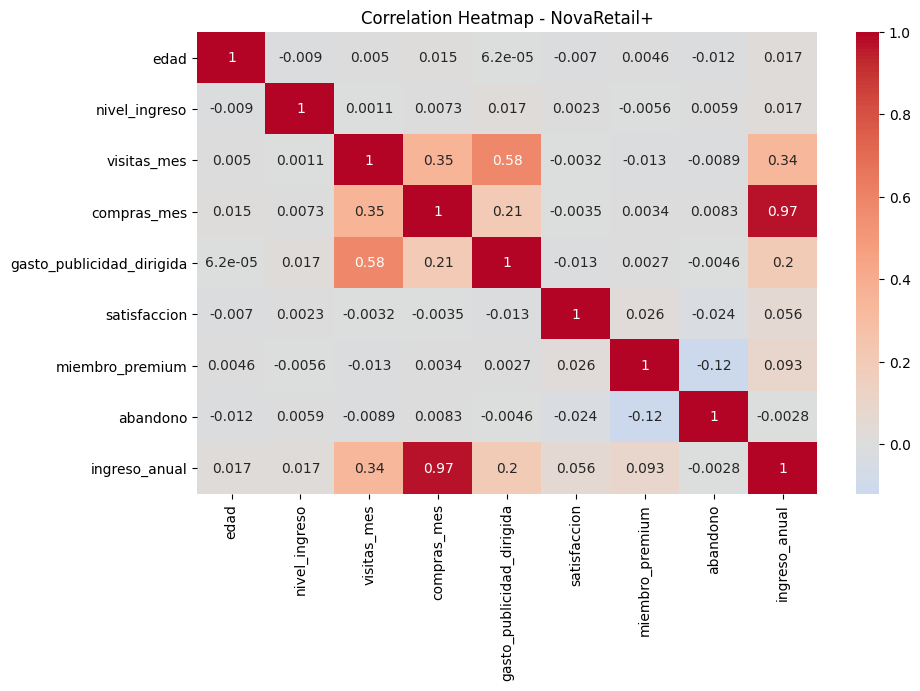

In [37]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaRetail+")
plt.show()


Observaciones generales (Heatmap)  
- Se observa una correlación positiva moderada entre visitas_mes y gasto_publicidad_dirigida (0.58), lo que sugiere que un mayor gasto en publicidad se asocia con un mayor número de visitas.
- También existe una correlación positiva debil entre visitas_mes y compras_mes (0.35), indicando que más visitas tienden a relacionarse con efectuar más compras.
- Hay una correlación positiva debil entre compras_mes y gasto_publicidad_dirigida, lo que sugirre que un mayor gasto en publicidad se asocia con más compras al mes. 
- La correlación entre miembro_premium y abandono es débil y negativa (-0.12), lo que sugiere que ser clientes premium se vincula con abandonar ligeramente menos la plataforma.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación positiva muy fuerte con compras_mes (0.97), indicando que un ingreso anual mayor se asocia al número de compras realizadas.
- Presenta una correlación positiva debil con visitas_mes (0.34), lo que sugiere que más visitas a la plataforma se relaciona con generar mayores ingresos.
- Tiene una correlación positiva débil con gasto_publicidad_dirigida (0.20) y con miembro_premium (0.09).



### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - **No se realiza un scatterplot general**, ya que el heatmap de correlación mostró que la mayoría de las variables presentan correlaciones muy bajas o cercanas a cero. Un gráfico general generaría muchas comparaciones con poca información relevante, dificultando la interpretación. Es más útil elaborar scatterplots únicamente para los pares de variables que presentan una correlación significativa.

### Scatterplot para pares clave

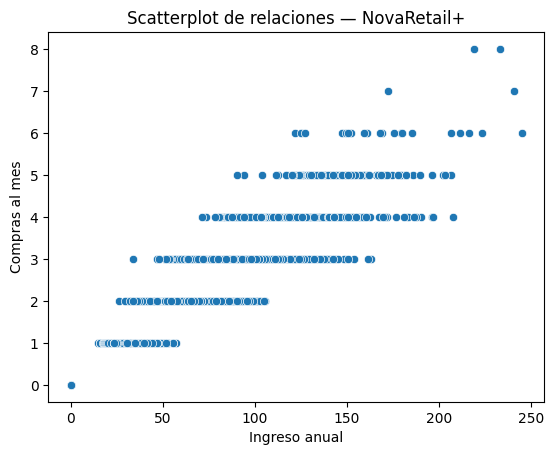

In [38]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(
    data=df,
    x="ingreso_anual",
    y="compras_mes"
)

plt.title("Scatterplot de relaciones — NovaRetail+")
plt.xlabel("Ingreso anual")
plt.ylabel("Compras al mes")
plt.show()


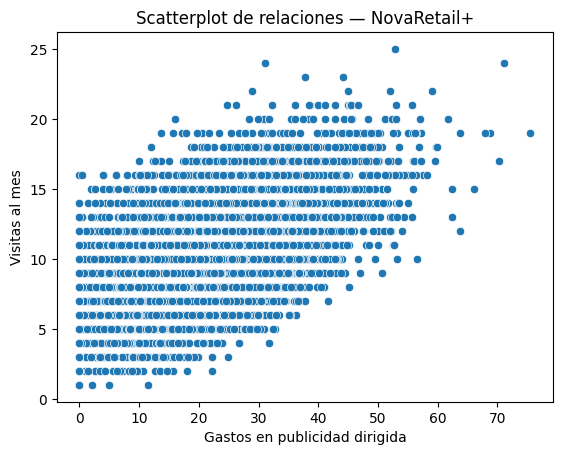

In [39]:
sns.scatterplot(
    data=df,
    x="gasto_publicidad_dirigida",
    y="visitas_mes"
)

plt.title("Scatterplot de relaciones — NovaRetail+")
plt.xlabel("Gastos en publicidad dirigida")
plt.ylabel("Visitas al mes")
plt.show()

Observaciones iniciales (Scatterplot)

**ingreso_anual vs compras_mes**
- Dirección: Positiva, a medida que aumenta el ingreso anual, también aumenta el número de compras mensuales.
- Dispersión: Es Baja, ya que los puntos siguen una tendencia ascendente bien definida.
- Outliers: No se observan valores atípicos importantes; la mayoría de los datos se concentran siguiendo el mismo patrón.
- Posible colinealidad: Sí. La relación es muy fuerte y coincide con la alta correlación observada en el heatmap (0.97), por lo que podría existir colinealidad entre estas variables.

**gasto_publicidad_dirigida vs visitas_mes**
- Dirección: Positiva, un mayor gasto en publicidad dirigida se asocia con un mayor número de visitas al mes.
- Dispersión: Es media, aunque existe una tendencia ascendente, los puntos presentan una mayor variabilidad que en el caso anterior.
- Outliers: Se observan algunos valores aislados con gastos y visitas elevados, pero no parecen alterar la tendencia general.
- Posible colinealidad: No se aprecia una colinealidad fuerte; la relación es moderada y consistente con la correlación obtenida en el heatmap (0.58).

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [40]:
# Calcular correlación entre variables relevantes
corr_pearson  = df['compras_mes'].corr(df['ingreso_anual'], method='pearson')
corr_spearman = df['compras_mes'].corr(df['ingreso_anual'], method='spearman')

print(f"Correlacion entre: compras_mes y compras")
print(f"Pearson: {corr_pearson:.3f}")
print(f"Spearman: {corr_spearman:.3f}")

Correlacion entre: compras_mes y compras
Pearson: 0.967
Spearman: 0.967


In [41]:
# Calcular correlación entre variables relevantes
corr_pearson  = df['visitas_mes'].corr(df['gasto_publicidad_dirigida'], method='pearson')
corr_spearman = df['visitas_mes'].corr(df['gasto_publicidad_dirigida'], method='spearman')

print(f"Correlacion entre: visitas_mes y gasto_publicidad_dirigida")
print(f"Pearson: {corr_pearson:.3f}")
print(f"Spearman: {corr_spearman:.3f}")

Correlacion entre: visitas_mes y gasto_publicidad_dirigida
Pearson: 0.579
Spearman: 0.559


Observaciones de correlación

**compras_mes vs ingreso_anual**
- Correlación: Positiva muy fuerte (0.96 en Pearson y 0.96 en Spearman), indicando una relación lineal muy marcada entre ambas variables.
- Existe una posible colinealidad, ya que ambas variables se encuentran altamente relacionadas.

**visitas_mes vs gasto_publicidad_dirigida**
- Correlación: Positiva moderada (0.57 en Pearson y 0.55 en Spearman), lo que indica que un mayor gasto en publicidad suele asociarse con un mayor número de visitas.
- No se aprecia una colinealidad fuerte, aunque sí una asociación moderada.

### Punto-biserial

In [42]:
# Calcular correlación entre variables relevantes


print(pointbiserialr(df["miembro_premium"], df["ingreso_anual"]))
print(pointbiserialr(df["abandono"], df["satisfaccion"]))


SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)
SignificanceResult(statistic=-0.02383256067380403, pvalue=0.003510976893362289)


Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación es positiva, y la magnitud de la relacion es baja. Los clientes con membresía premium tienden a generar un ingreso anual ligeramente mayor.

**abandono vs satisfaccion**
- Relación es negativa y la magnitud de la relación es practicamente nula. A medida que aumenta la satisfacción del cliente, la probabilidad de abandono disminuye ligeramente.

### V de Cramér

In [43]:
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    return v

In [44]:
# Aplicar V de Cramér en variables relevantes

v = cramer_v(df, "tipo_dispositivo", "region")
print(f"V de Cramér: {v:.4f}")

V de Cramér: 0.0124


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
- Se obtuvo un V de Cramér de 0.0124, lo que indica una asociación prácticamente nula entre ambas variables categóricas.
- Esto sugiere que el tipo de dispositivo utilizado por los clientes no depende de la región a la que pertenecen.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---


### Hallazgo 1 — Las compras mensuales están fuertemente relacionadas con el ingreso anual.

**Evidencia visual:** Scatterplot entre `compras_mes` e `ingreso_anual`.

**Evidencia numérica:** Correlación de Pearson = **0.967**, Correlación de Spearman = **0.967**.

**Interpretación**
Se observa una relación positiva muy fuerte entre ambas variables: los clientes que realizan más compras al mes tienden a generar un mayor ingreso anual.

**No podemos afirmar**
No se puede concluir que aumentar el número de compras sea la causa directa del incremento en el ingreso anual, ya que la correlación no implica causalidad y pueden intervenir otros factores.

**Implicación de negocio**
Podría ser útil diseñar estrategias que incentiven la frecuencia de compra, ya que existe una fuerte asociación entre ambas variables.


### Hallazgo 2 — La inversión en publicidad dirigida presenta una relación moderada con las visitas mensuales.

**Evidencia visual:** Scatterplot entre `gasto_publicidad_dirigida` y `visitas_mes`.

**Evidencia numérica:** Correlación de Pearson = **0.579**, Correlacion de Spearman = **0.559**.

**Interpretación**
Se observa una relación positiva moderada, lo que sugiere que un mayor gasto en publicidad suele asociarse con un mayor número de visitas al sitio.

**No podemos afirmar**
No es posible asegurar que la publicidad sea la única responsable del aumento en las visitas, ya que otros factores pueden influir en el comportamiento de los clientes.

**Implicación de negocio**
Se podrían evaluar campañas de publicidad para determinar cuáles generan un mayor impacto en el tráfico y optimizar la inversión.


### Hallazgo 3 — Las variables categóricas analizadas no muestran una asociación relevante.

**Evidencia visual:** No aplica.

**Evidencia numérica:** V de Cramér (`tipo_dispositivo` vs `region`) = **0.0124**.

**Interpretación**
La asociación entre el tipo de dispositivo utilizado y la región es prácticamente nula, lo que sugiere que ambas variables son independientes.

**No podemos afirmar**
No puede afirmarse que la región influya en el tipo de dispositivo utilizado por los clientes.

**Implicación de negocio**
Las estrategias relacionadas con dispositivos probablemente no requieran segmentarse por región y pueden analizarse de forma independiente.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
### Limitaciones
- Las correlaciones identificadas muestran asociaciones entre variables, pero **no permiten establecer relaciones de causalidad**.
- Es posible que existan variables no medidas que influyan en los resultados, como promociones, estacionalidad, hábitos de compra o factores socioeconómicos.
- El análisis se basa en un conjunto de datos específico, por lo que los resultados podrían no generalizarse a otros periodos o poblaciones.
- Algunas relaciones observadas son débiles, por lo que deben interpretarse con cautela y complementarse con otros análisis.

### **Próximos pasos** 
- Segmentar a los clientes por características como región, nivel de ingresos, membresía premium o frecuencia de compra para identificar patrones específicos.
- Analizar el comportamiento de los clientes con modelos predictivos que permitan identificar factores asociados a un mayor ingreso o al abandono.
- Incorporar nuevas variables, como historial de compras, tipo de productos adquiridos, descuentos utilizados o tiempo como cliente, para enriquecer el análisis y obtener conclusiones más completas.